Cloning into 'GreenPulse'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 91 (delta 40), reused 30 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 15.52 MiB | 24.04 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/GreenPulse
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


100%|██████████| 534M/534M [00:27<00:00, 20.6MB/s] 

Extracting files...


/kaggle/input/plantvillage-dataset
/root/.cache/kagglehub/datasets/karagwaanntreasure/plant-disease-detection/versions/1
Class mapping defined for 7 unified target classes
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Using Colab cache for faster access to the 'plant-disease-detection' dataset.


100%|██████████| 1.01G/1.01G [00:39<00:00, 27.2MB/s]

Extracting files...


Cleaned dataset! Removed 5484 duplicate images.

Clean Unified Dataset Structure:
  └─ Maize_Northern_Leaf_Blight: 2116 unique images
  └─ Tomato_Late_Blight: 1901 unique images
  └─ Tomato_Healthy: 1585 unique images
  └─ Maize_Healthy: 2084 unique images
  └─ Cocoa_Healthy: 3344 unique images
  └─ Cocoa_Pod_Borer: 103 unique images
  └─ Cocoa_Black_Pod_Rot: 943 unique images
  └─ Tomato_Leaf_Mold: 952 unique images
  └─ Maize_Common_Rust: 2144 unique images
  └─ Tomato_Early_Blight: 1000 unique images


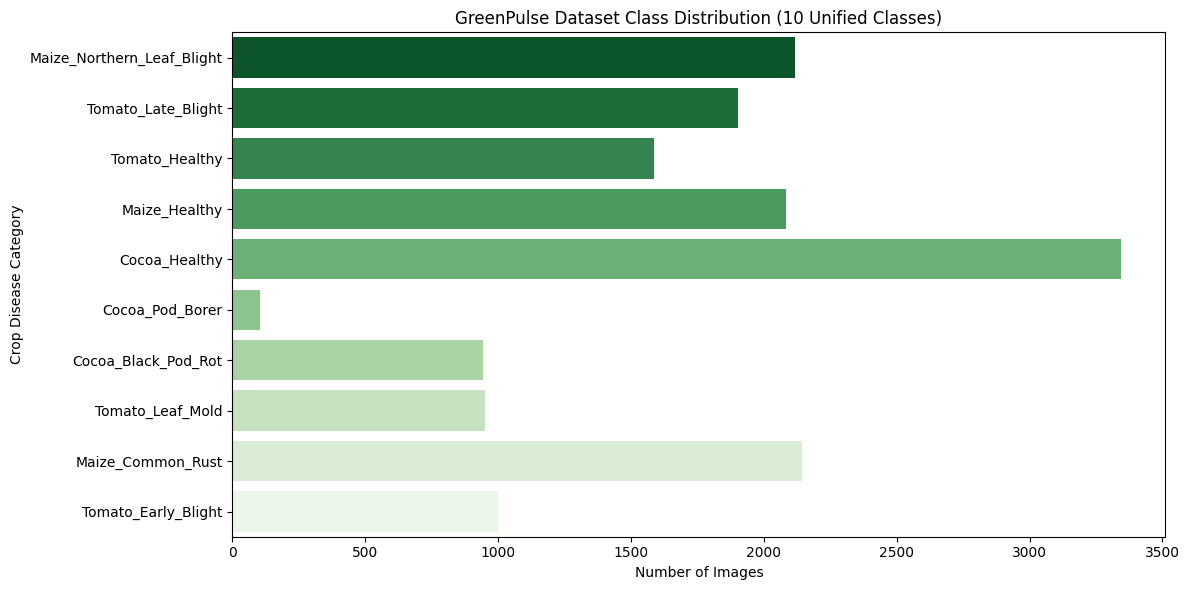

In [1]:
!git clone https://github.com/KekeliIsHere/GreenPulse.git
%cd GreenPulse
%run notebooks/00_data_exploration_and_cleaning.ipynb

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: False


In [3]:
from pathlib import Path

dataset_path = Path("/content/clean_crop_dataset")
print(dataset_path.exists())

True


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, DataLoader, Subset


torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



Using device: cpu


In [ ]:
# Augmentating the images to let the model learn from  different versions of
# the same image across epochs.
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Transform the test data
test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
# Loading the full dataset
full_dataset = ImageFolder(root=dataset_path, transform=train_transform)

# Then run splits
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

print("Train:", train_size)
print("Validation:", val_size)
print("Test:", test_size)

Train: 11320
Validation: 2425
Test: 2427


In [ ]:
generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    total_size,
    generator=generator
).tolist()

In [ ]:
train_indices = indices[:train_size]

val_indices = indices[
    train_size:
    train_size + val_size
]

test_indices = indices[
    train_size + val_size:
]

In [10]:
train_dataset = ImageFolder(
    root=dataset_path,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=dataset_path,
    transform=test_transform
)

test_dataset = ImageFolder(
    root=dataset_path,
    transform=test_transform
)



In [ ]:

train_ds = Subset(
    train_dataset,
    train_indices
)

val_ds = Subset(
    val_dataset,
    val_indices
)

test_ds = Subset(
    test_dataset,
    test_indices
)

In [12]:
# creating the dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [13]:
print("Training images:", len(train_ds))
print("Validation images:", len(val_ds))
print("Test images:", len(test_ds))

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training images: 11320
Validation images: 2425
Test images: 2427
Training batches: 354
Validation batches: 76
Test batches: 76


In [14]:
# Checking training batch before training
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([32, 3, 224, 224])
torch.Size([32])


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GreenPulseCustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(GreenPulseCustomCNN, self).__init__()

        # Block 1: Input (3, 224, 224) -> (32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2: (32, 112, 112) -> (64, 56, 56)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3: (64, 56, 56) -> (128, 28, 28)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Pooling & Dropout
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.3)

        # Fully Connected Classifier: 128 * 28 * 28 = 100,352 features
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Feature Extraction
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Flatten
        x = torch.flatten(x, 1)

        # Dense Layers
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Initialize custom model
NUM_CLASSES = len(train_dataset.classes)
model = GreenPulseCustomCNN(num_classes=NUM_CLASSES).to(device)

print(f"✅ Custom GreenPulse CNN initialized from scratch for {NUM_CLASSES} classes!")

✅ Custom GreenPulse CNN initialized from scratch for 10 classes!


In [ ]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    avg_loss = running_loss / total
    accuracy = correct / total
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return avg_loss, accuracy, preds, labels

In [ ]:
def fit(model, epochs=5, lr=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        print(f"Epoch {epoch:2d}/{epochs} | "
              f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.3f} acc {va_acc:.3f}")
    return history

In [18]:
custom_model = GreenPulseCustomCNN(num_classes=10).to(device)
history_custom = fit(
    model=custom_model,
    epochs=10,
    lr=1e-3
)


Epoch  1/10 | train loss 1.630 acc 0.688 | val loss 0.412 acc 0.827
Epoch  2/10 | train loss 0.632 acc 0.770 | val loss 0.426 acc 0.847
Epoch  3/10 | train loss 0.574 acc 0.797 | val loss 0.388 acc 0.864
Epoch  4/10 | train loss 0.522 acc 0.807 | val loss 0.403 acc 0.861
Epoch  5/10 | train loss 0.510 acc 0.818 | val loss 0.392 acc 0.869
Epoch  6/10 | train loss 0.467 acc 0.835 | val loss 0.305 acc 0.883
Epoch  7/10 | train loss 0.484 acc 0.828 | val loss 0.355 acc 0.892
Epoch  8/10 | train loss 0.447 acc 0.843 | val loss 0.342 acc 0.878
Epoch  9/10 | train loss 0.462 acc 0.840 | val loss 0.295 acc 0.898
Epoch 10/10 | train loss 0.424 acc 0.850 | val loss 0.239 acc 0.920


In [19]:
print(history_custom)

{'train_loss': [1.629665333980385, 0.6317652538892659, 0.5739531219637436, 0.5218967883409965, 0.5095173462751477, 0.46749689048254867, 0.48419925286154863, 0.4465333454284567, 0.4619929461618194, 0.42427592608195736], 'train_acc': [0.6877208480565371, 0.7698763250883393, 0.7971731448763251, 0.8073321554770319, 0.8184628975265018, 0.8352473498233216, 0.8277385159010601, 0.842756183745583, 0.8403710247349824, 0.8499116607773851], 'val_loss': [0.41160804613349367, 0.4259100064543105, 0.3879127810787909, 0.403271265423175, 0.39160993330257454, 0.3046322469612987, 0.35505196571350095, 0.34223021391740777, 0.2951491116002663, 0.23949630348952775], 'val_acc': [0.8268041237113402, 0.8470103092783505, 0.8643298969072165, 0.8610309278350515, 0.8688659793814433, 0.883298969072165, 0.8923711340206185, 0.8779381443298969, 0.8977319587628866, 0.9195876288659793]}


In [20]:
torch.save(custom_model.state_dict(), "custom_greenpulse_model.pth")
print("Custom model trained and saved successfully!")

Custom model trained and saved successfully!


In [21]:
import os

print(os.path.exists("custom_greenpulse_model.pth"))
print(f"Model size: {os.path.getsize('custom_greenpulse_model.pth') / (1024**2):.2f} MB")

True
Model size: 98.38 MB


In [22]:
from google.colab import files

files.download("custom_greenpulse_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>